<a href="https://colab.research.google.com/github/saixg/MLE-EDA-EXPLORER/blob/main/iris/mle_eda(i).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import all libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.cluster import KMeans

sns.set_theme(style="whitegrid", palette="muted")

# Load Iris directly from sklearn — no file download needed
iris_raw = load_iris(as_frame=True)
iris = iris_raw.frame

# Add a readable species name column alongside the numeric target
iris['species'] = iris['target'].map(dict(enumerate(iris_raw.target_names)))

print("Shape:", iris.shape)
print("\nClasses:", iris_raw.target_names.tolist())
print("\nFirst 5 rows:")
iris.head()

Shape: (150, 6)

Classes: ['setosa', 'versicolor', 'virginica']

First 5 rows:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


In [2]:
# Separate features and label
X = iris.drop(columns=['target', 'species'])
y = iris['species']

print("Features (X):", X.columns.tolist())
print("Label    (y): species →", y.unique().tolist())

print("\n--- Data types ---")
print(X.dtypes)

print("\nAll features are numerical (float64) — no encoding required.")

Features (X): ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Label    (y): species → [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]

--- Data types ---
sepal length (cm)    float64
sepal width (cm)     float64
petal length (cm)    float64
petal width (cm)     float64
dtype: object

All features are numerical (float64) — no encoding required.


In [3]:
# Check for missing values across the full dataset
missing = iris.isnull().sum()
pct     = (missing / len(iris) * 100).round(1)

missing_df = pd.DataFrame({'missing_count': missing, 'missing_pct': pct})
print(missing_df.to_string())

if missing.sum() == 0:
    print("\nNo missing values found. Dataset is complete.")
else:
    print("\nMissing values detected — imputation required.")

                   missing_count  missing_pct
sepal length (cm)              0          0.0
sepal width (cm)               0          0.0
petal length (cm)              0          0.0
petal width (cm)               0          0.0
target                         0          0.0
species                        0          0.0

No missing values found. Dataset is complete.


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333
std,0.828066,0.435866,1.765298,0.762238
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000



Class balance:
species
setosa        50
versicolor    50
virginica     50


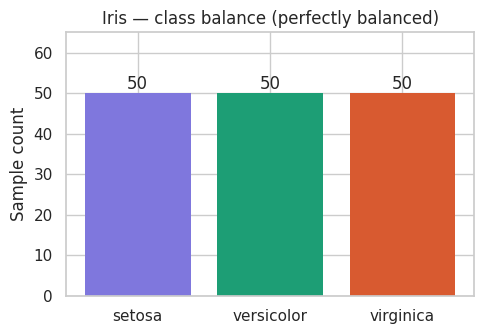

In [4]:
# Descriptive statistics
display(X.describe())

# Class balance
balance = y.value_counts()
print("\nClass balance:")
print(balance.to_string())

fig, ax = plt.subplots(figsize=(5, 3.5))
ax.bar(balance.index, balance.values,
      color=['#7F77DD', '#1D9E75', '#D85A30'], edgecolor='none')
ax.set_title('Iris — class balance (perfectly balanced)')
ax.set_ylabel('Sample count')
ax.set_ylim(0, 65)
for i, v in enumerate(balance.values):
    ax.text(i, v + 1, str(v), ha='center', fontsize=12)
plt.tight_layout(); plt.show()

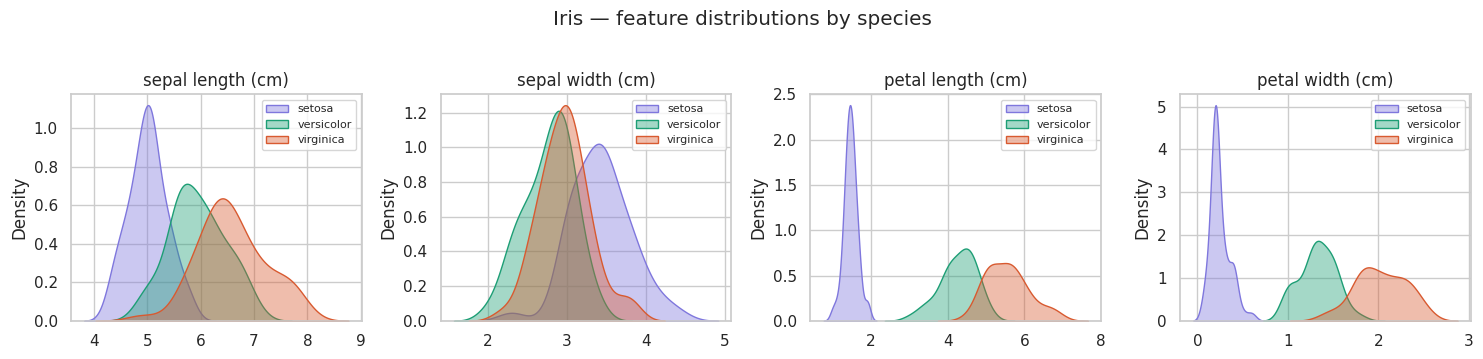

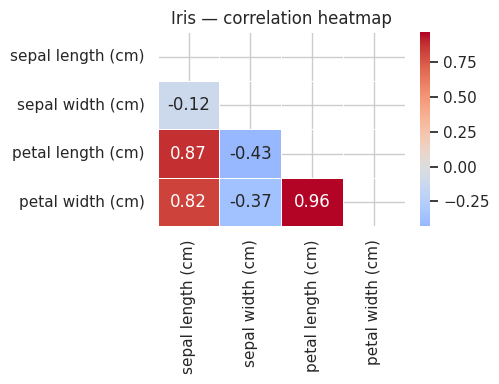

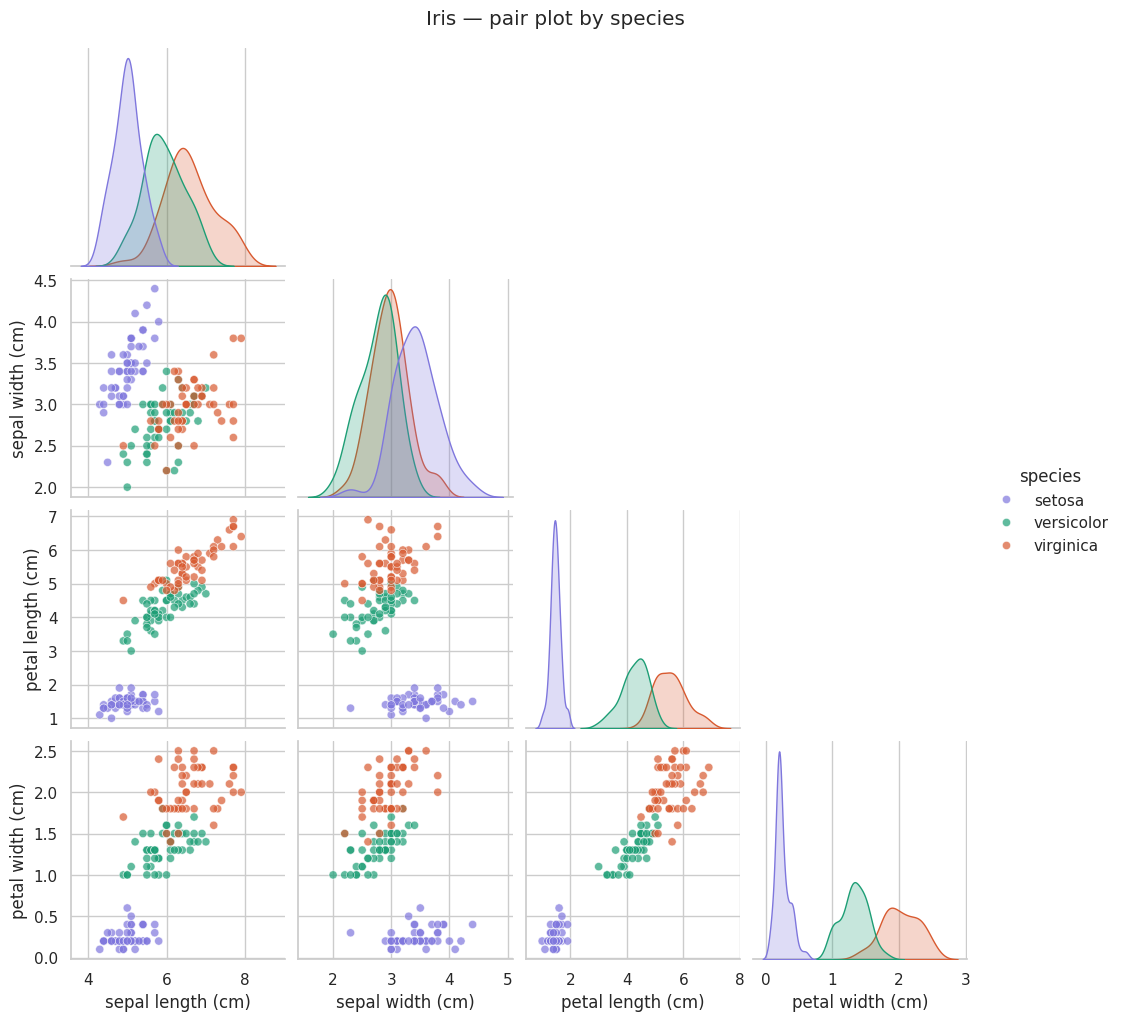

/tmp/ipykernel_9487/2255800211.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=iris, x='species', y=col,
/tmp/ipykernel_9487/2255800211.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=iris, x='species', y=col,
/tmp/ipykernel_9487/2255800211.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=iris, x='species', y=col,
/tmp/ipykernel_9487/2255800211.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for

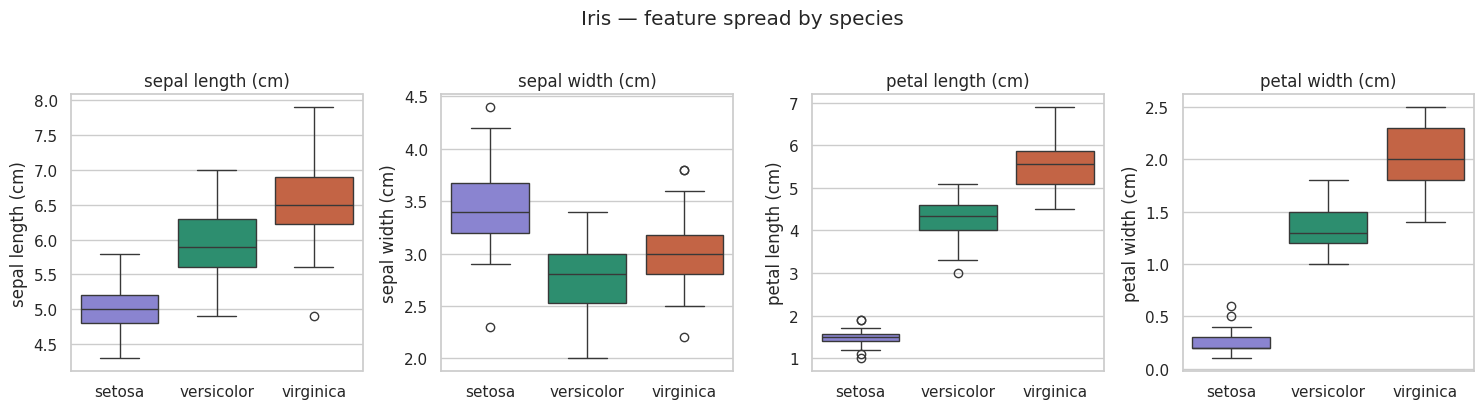

In [5]:
# --- 1. KDE plots for all 4 features, split by species ---
palette = {'setosa': '#7F77DD', 'versicolor': '#1D9E75', 'virginica': '#D85A30'}

fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
for ax, col in zip(axes, X.columns):
    for species, color in palette.items():
        sns.kdeplot(iris[iris.species == species][col],
                    ax=ax, label=species, color=color,
                    fill=True, alpha=0.4)
    ax.set_title(col); ax.set_xlabel(""); ax.legend(fontsize=8)
fig.suptitle('Iris — feature distributions by species', y=1.02)
plt.tight_layout(); plt.show()

# --- 2. Correlation heatmap ---
fig, ax = plt.subplots(figsize=(5, 4))
corr = X.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f",
            cmap="coolwarm", center=0, ax=ax, linewidths=0.5)
ax.set_title('Iris — correlation heatmap')
plt.tight_layout(); plt.show()

# --- 3. Pair plot (the star of Iris EDA) ---
pair_df = X.copy()
pair_df['species'] = y
g = sns.pairplot(pair_df, hue='species',
                  palette=palette, corner=True,
                  plot_kws={'alpha': 0.7, 's': 35})
g.fig.suptitle('Iris — pair plot by species', y=1.02)
plt.show()

# --- 4. Box plots — spread per species ---
fig, axes = plt.subplots(1, 4, figsize=(15, 4))
for ax, col in zip(axes, X.columns):
    sns.boxplot(data=iris, x='species', y=col,
                palette=palette, ax=ax, linewidth=1)
    ax.set_title(col); ax.set_xlabel("")
fig.suptitle('Iris — feature spread by species', y=1.02)
plt.tight_layout(); plt.show()

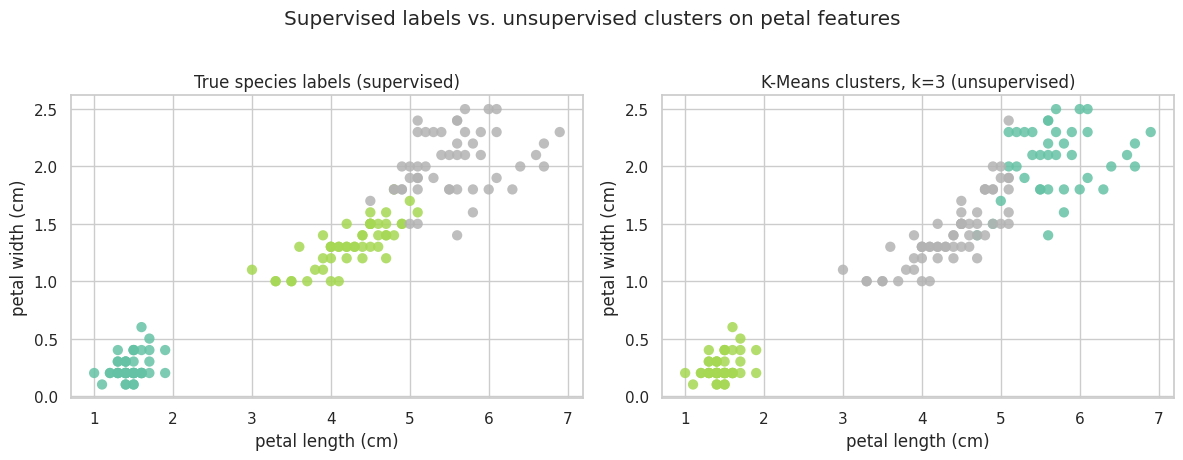

The two plots should look nearly identical —
K-Means re-discovered the species groupings without ever seeing the labels.


In [6]:
# Run K-Means with k=3 — no labels used
km = KMeans(n_clusters=3, random_state=42, n_init='auto')
cluster_labels = km.fit_predict(X)

# Map numeric species to 0/1/2 for color plotting
species_num = y.map({'setosa': 0, 'versicolor': 1, 'virginica': 2})

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

for ax, colors, title in zip(
    axes,
    [species_num, cluster_labels],
    ["True species labels (supervised)",
     "K-Means clusters, k=3 (unsupervised)"]
):
    sc = ax.scatter(
        X['petal length (cm)'], X['petal width (cm)'],
        c=colors, cmap='Set2', s=55, alpha=0.85, edgecolors='none'
    )
    ax.set_title(title)
    ax.set_xlabel('petal length (cm)')
    ax.set_ylabel('petal width (cm)')

plt.suptitle('Supervised labels vs. unsupervised clusters on petal features',
             y=1.02)
plt.tight_layout(); plt.show()

print("The two plots should look nearly identical —")
print("K-Means re-discovered the species groupings without ever seeing the labels.")

In [7]:
# 80/20 stratified split
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("=== Iris 80/20 Split ===")
print(f"X_train : {X_train.shape}   X_test : {X_test.shape}")
print(f"y_train : {y_train.shape}   y_test : {y_test.shape}")

print("\nTrain class counts:")
print(y_train.value_counts().to_string())

print("\nTest class counts:")
print(y_test.value_counts().to_string())
print("\nEach class has equal representation in both sets (stratified ✓)")

=== Iris 80/20 Split ===
X_train : (120, 4)   X_test : (30, 4)
y_train : (120,)   y_test : (30,)

Train class counts:
species
setosa        40
virginica     40
versicolor    40

Test class counts:
species
setosa        10
virginica     10
versicolor    10

Each class has equal representation in both sets (stratified ✓)


In [ ]:
"""
## Final EDA report — Iris
### Data quality
Zero missing values — no imputation needed
Perfectly balanced: 50 samples per class
All features are numerical floats — no encoding needed

### Key insights from EDA:-

Petal length and petal width are the most discriminative features — near-perfect separation visible in KDE plots and the pair plot
Setosa is completely linearly separable from the other two species on petal features
Versicolor and Virginica overlap slightly — models will need to handle this boundary carefully
High correlation (~0.96) between petal length and petal width — consider dropping one if using linear models to avoid multicollinearity
K-Means (k=3) nearly perfectly re-discovered the true species without labels — strong evidence the features are genuinely predictive
### Preprocessing steps needed before modeling
Feature scaling (StandardScaler or MinMaxScaler) — required for SVM, k-NN, Logistic Regression, and K-Means
Label encoding — encode species as 0/1/2 for most sklearn classifiers
No imputation, no categorical encoding needed


"""
